# Generalized Additive Model (GAM) Periyar - Combined

In [4]:
! pip install mlxtend

In [6]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import sklearn.metrics as metrics

# libraries for Multicollinearity
from sklearn.linear_model import LinearRegression

#libraries for feature selection
from sklearn.feature_selection import RFE
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

# libraries for optimize hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  # MaxEnt Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

In [8]:
# Load dataset
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Combined_Multi_ML.csv"
df = pd.read_csv(csv_path)
df.drop(columns=["wkt_geom"], inplace=True, errors="ignore")


In [10]:

num_rows, num_columns = df.shape
print(f"Total Rows: {num_rows}")
print(f"Total Columns: {num_columns}")

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

Total Rows: 6432
Total Columns: 29

First 5 Rows:
    Aspect1  DistToRoad  DistToStre  Elevation1  FlowDir1  LULC1     NDBI1  \
0  0.452086   30.002138  212.132034    0.083799  0.450980     10  0.445073   
1       NaN   42.430210  276.586334    0.064516  0.988858     10       NaN   
2       NaN  180.013779  150.000000    0.084375  0.587744     50       NaN   
3       NaN   67.090622   84.852814    0.266667  0.806723     10       NaN   
4       NaN   84.861305  228.473190    0.034562  0.376045     50       NaN   

      NDVI1     NDWI1  PlanarCurv  ...  Rainfall10  Rainfall11    Slope1  \
0  0.667561  0.271971    0.547924  ...   24.256168   11.560450  0.091731   
1       NaN       NaN         NaN  ...   22.843584   10.719832       NaN   
2       NaN       NaN         NaN  ...   21.774399   10.319216       NaN   
3       NaN       NaN         NaN  ...   22.437412   10.466014       NaN   
4       NaN       NaN         NaN  ...   22.843584   10.719832       NaN   

       SPI1      STI1   

In [11]:
!pip install pygam

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_auc_score
)
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import ClusterCentroids
from pygam import LogisticGAM, s
from functools import reduce

# Load dataset
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Combined_Multi_ML.csv"
df = pd.read_csv(csv_path)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Prepare features and target
X = df.drop(columns=["Target_Var", "wkt_geom"], errors="ignore").fillna(0)
y = df["Target_Var"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# ==== Apply Cluster Centroids (Undersampling Majority Class) ====
cc = ClusterCentroids(random_state=42)
X_train_res, y_train_res = cc.fit_resample(X_train, y_train)

# ==== Apply Borderline SMOTE (Oversampling Minority Class) ====
smote = BorderlineSMOTE(random_state=42, kind='borderline-1')  # 'borderline-1' for minority class focus
X_train_res, y_train_res = smote.fit_resample(X_train_res, y_train_res)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Create GAM terms for each feature
terms = reduce(lambda a, b: a + b, [s(i, n_splines=10) for i in range(X.shape[1])])

# Unique classes in the target variable
classes = sorted(y.unique())

# Train OvR GAMs (One-vs-Rest)
gam_models = {}
for c in classes:
    # Binarize target for each class (1 for the class, 0 for others)
    y_binary = (y_train_res == c).astype(int)
    gam = LogisticGAM(terms).gridsearch(X_train_scaled, y_binary, lam=np.logspace(-3, 3, 7))
    gam_models[c] = gam

# Predict class with highest probability (OvR strategy)
proba_matrix = np.column_stack([gam.predict_proba(X_test_scaled) for gam in gam_models.values()])
y_pred = np.argmax(proba_matrix, axis=1)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision_weighted = precision_score(y_test, y_pred, average='weighted')
precision_macro = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Binarize for multiclass ROC-AUC calculation
y_test_bin = label_binarize(y_test, classes=classes)
roc_auc = roc_auc_score(y_test_bin, proba_matrix, multi_class='ovr')

# Report results
print("\n=== Multi-Class GAM (OvR) Evaluation ===")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Precision (macro)   : {precision_macro:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC AUC (OvR)  : {roc_auc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


 14% (1 of 7) |###                       | Elapsed Time: 0:00:05 ETA:   0:00:33

did not converge


100% (7 of 7) |##########################| Elapsed Time: 0:00:07 Time:  0:00:070:01
 14% (1 of 7) |###                       | Elapsed Time: 0:00:02 ETA:   0:00:15

did not converge


100% (7 of 7) |##########################| Elapsed Time: 0:00:05 Time:  0:00:050:00
 14% (1 of 7) |###                       | Elapsed Time: 0:00:05 ETA:   0:00:31

did not converge


100% (7 of 7) |##########################| Elapsed Time: 0:00:07 Time:  0:00:070:01



=== Multi-Class GAM (OvR) Evaluation ===
Accuracy       : 0.6523
Precision (weighted): 0.7163
Precision (macro)   : 0.6811
Recall         : 0.6523
F1 Score       : 0.6396
ROC AUC (OvR)  : 0.8403

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.44      0.58       965
           1       0.68      0.84      0.75       441
           2       0.53      0.88      0.66       524

    accuracy                           0.65      1930
   macro avg       0.68      0.72      0.66      1930
weighted avg       0.72      0.65      0.64      1930


Confusion Matrix:
 [[424 168 373]
 [ 31 372  38]
 [ 53   8 463]]


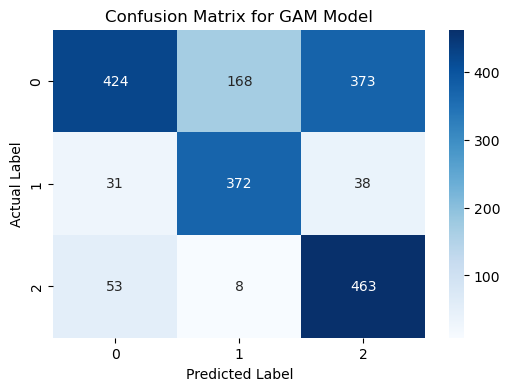

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for GAM Model")
plt.show()


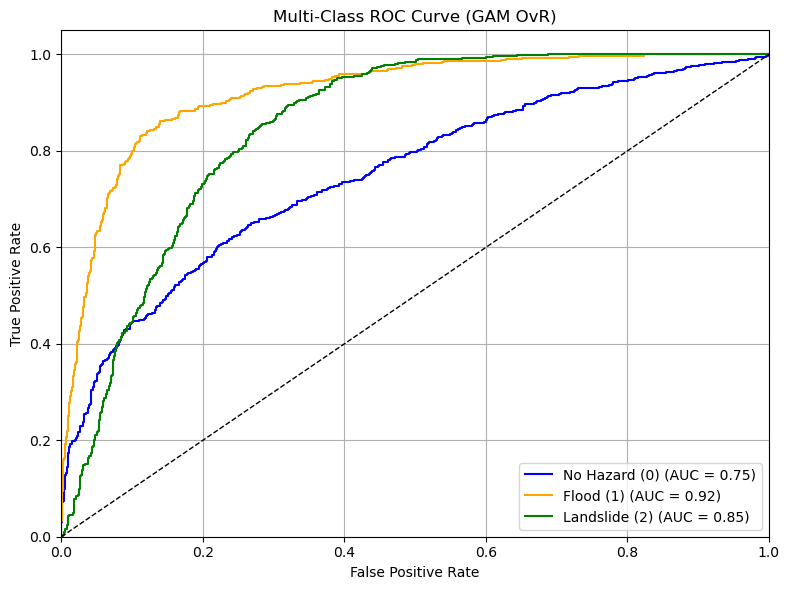

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC for each class
fpr = dict()
tpr = dict()
roc_auc_per_class = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], proba_matrix[:, i])
    roc_auc_per_class[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']
labels = ['No Hazard (0)', 'Flood (1)', 'Landslide (2)']

for i, class_label in enumerate(labels):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f"{class_label} (AUC = {roc_auc_per_class[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (GAM OvR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
import pandas as pd

# proba_matrix: combined predicted probabilities from OvR GAMs
# y_pred: predicted labels (argmax of proba_matrix)

df_gam = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred,
    'Prob_Class_0': proba_matrix[:, 0],
    'Prob_Class_1': proba_matrix[:, 1],
    'Prob_Class_2': proba_matrix[:, 2]
})

save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\GAM_Combined_Results.csv"
df_gam.to_csv(save_path, index=False)

print(f"Saved GAM multi-class predictions to {save_path}")


Saved GAM multi-class predictions to C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\GAM_Combined_Results.csv


100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
PermutationExplainer explainer: 1049it [03:23,  4.97it/s]                          


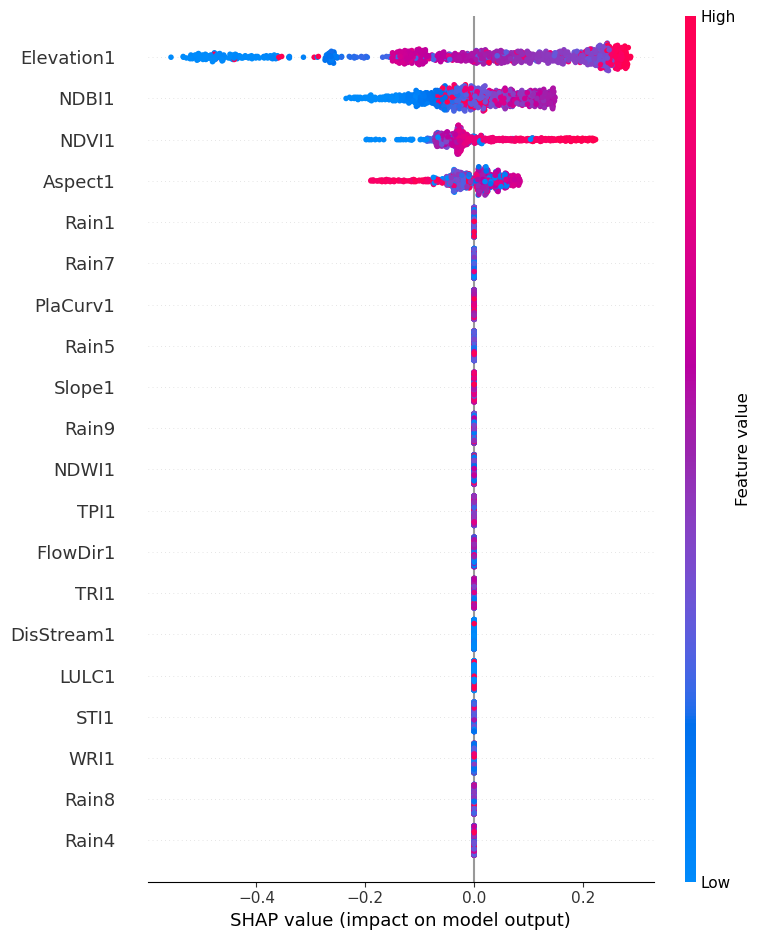

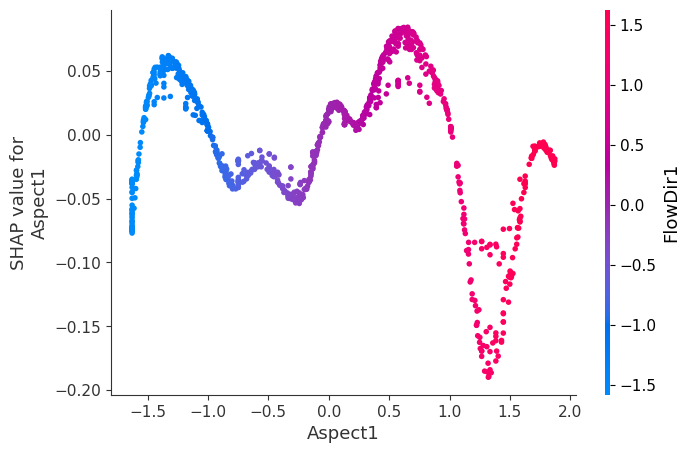

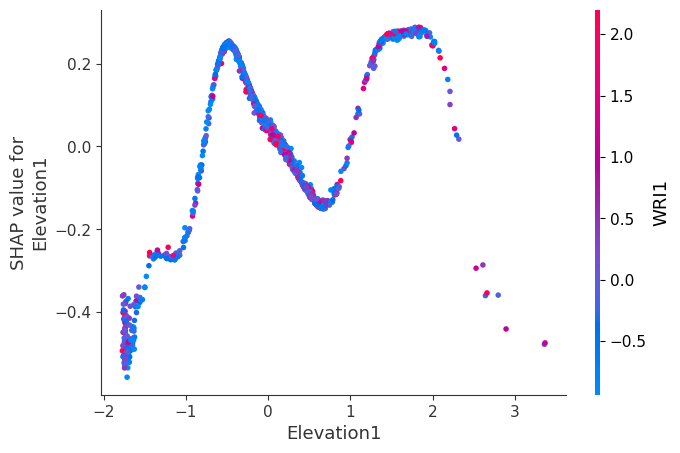

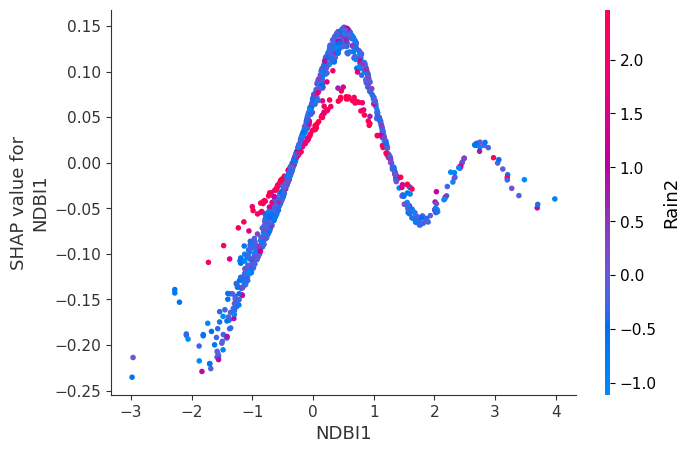

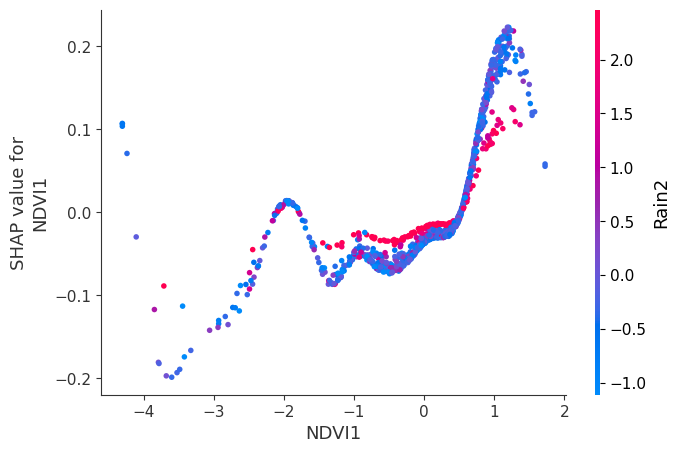

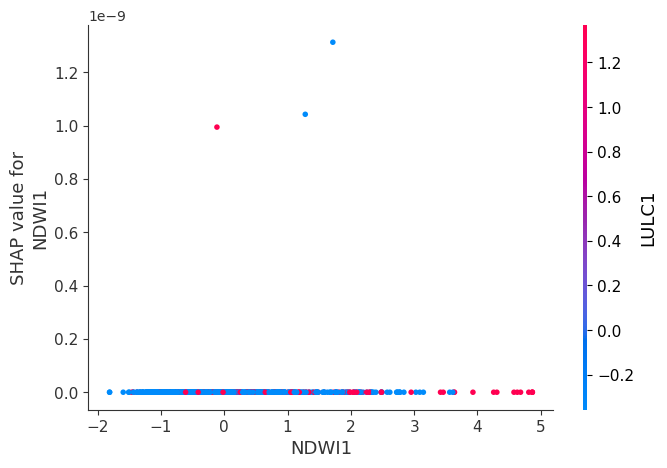


Feature Ranking based on SHAP Values:
       Feature  SHAP Importance
1   Elevation1     1.850929e-01
2        NDBI1     7.084079e-02
3        NDVI1     6.247121e-02
0      Aspect1     4.206087e-02
13       Rain1     1.774918e-11
19       Rain7     1.732299e-11
7     PlaCurv1     1.106251e-11
17       Rain5     9.008665e-12
6       Slope1     8.571926e-12
21       Rain9     8.545751e-12


In [24]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pygam import LogisticGAM, s
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **Step 1: Retrieve feature names before standardization**
feature_names = X.columns  # Save original feature names

# **Step 2: Convert X_train and X_test to Dense Matrices**
scaler = StandardScaler()
X_train = np.array(scaler.fit_transform(X_train), dtype=np.float64)  # ✅ Ensures it's a dense array
X_test = np.array(scaler.transform(X_test), dtype=np.float64)  # ✅ Ensures it's a dense array

# **Step 3: Train GAM Model (Ensure it's fitted)**
gam = LogisticGAM(s(0) + s(1) + s(2) + s(3))  # Adjust based on number of features
gam.gridsearch(X_train, y_train)  # ✅ Hyperparameter tuning
gam.fit(X_train, y_train)  # ✅ Ensure GAM is fitted

# **Step 4: Define SHAP Explainer for GAM**
explainer = shap.Explainer(gam.predict_proba, X_train)  # SHAP for GAM

# **Step 5: Compute SHAP Values**
shap_values = explainer(X_test)

# **Step 6: SHAP Summary Plot (Global Feature Importance)**
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

# **Step 7: SHAP Dependence Plots for Top Features**
for feature_idx in range(min(5, len(feature_names))):  # Limit to top 5 features for clarity
    shap.dependence_plot(feature_idx, shap_values.values, X_test, feature_names=feature_names)

# **Step 8: Feature Ranking using SHAP Values**
shap_mean_contributions = np.abs(shap_values.values).mean(axis=0)  # Mean absolute SHAP values per feature
feature_ranking = pd.DataFrame({'Feature': feature_names, 'SHAP Importance': shap_mean_contributions})
feature_ranking = feature_ranking.sort_values(by="SHAP Importance", ascending=False)

print("\nFeature Ranking based on SHAP Values:")
print(feature_ranking.head(10))  # Show top 10 important features
